<a href="https://colab.research.google.com/github/krish3453/Machine_Learning/blob/main/FunctionTransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [9]:
df = pd.read_csv("https://raw.githubusercontent.com/rolandmueller/titanic/main/titanic3.csv",usecols=['age','fare','survived'])

In [10]:
df['age'] = df['age'].fillna(df['age'].mean())
X=df.iloc[:,1:3]
Y=df.iloc[:,0]

In [11]:
df.head()

,survived,age,fare
0,1,29.0000,211.3375
1,1,0.9167,151.5500
2,0,2.0000,151.5500
3,0,30.0000,151.5500
4,0,25.0000,151.5500


In [19]:
from numpy.random.mtrand import random
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

/tmp/ipykernel_2160/684135444.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['age'])


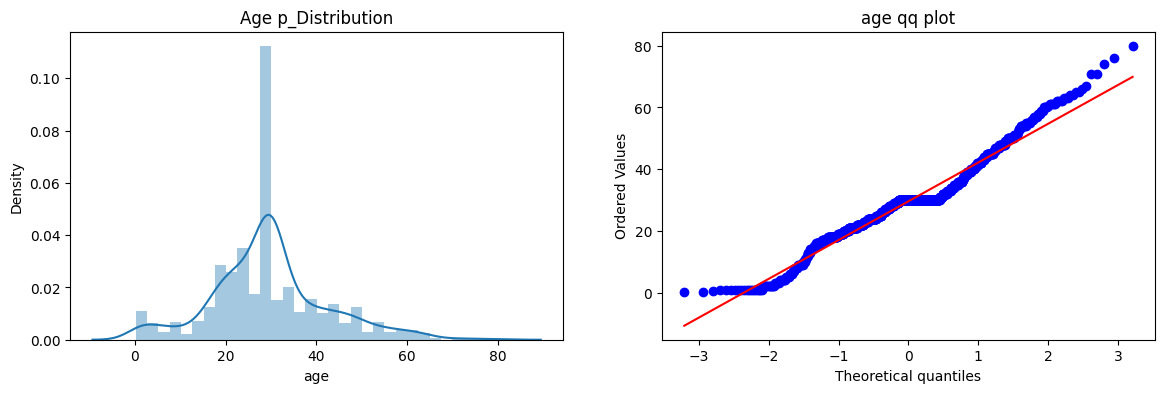

In [20]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['age'])
plt.title('Age p_Distribution')


plt.subplot(122)
stats.probplot(X_train['age'],dist="norm",plot=plt)
plt.title('age qq plot')
plt.show()

/tmp/ipykernel_2160/4092535768.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['fare'])


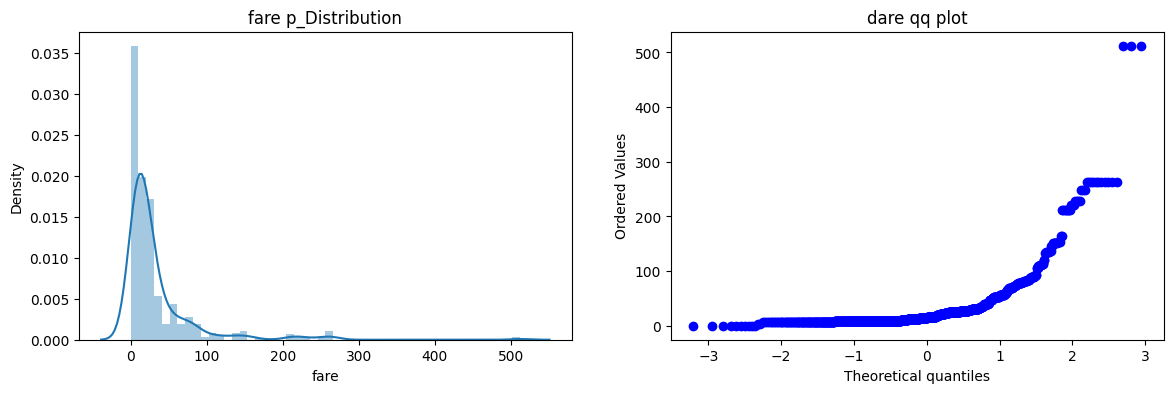

In [21]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['fare'])
plt.title('fare p_Distribution')


plt.subplot(122)
stats.probplot(X_train['fare'],dist="norm",plot=plt)
plt.title('dare qq plot')
plt.show()

In [22]:
trf=FunctionTransformer(np.log1p)
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

In [31]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
X_train_trf = X_train_trf.fillna(X_train_trf.mean())
X_test_trf = X_test_trf.fillna(X_train_trf.mean())


clf.fit(X_train_trf,Y_train)
clf2.fit(X_train_trf,Y_train)

y_pred=clf.predict(X_test_trf)
y_pred2=clf2.predict(X_test_trf)

print(accuracy_score(Y_test,y_pred))
print(accuracy_score(Y_test,y_pred2))


0.6603053435114504
0.6679389312977099


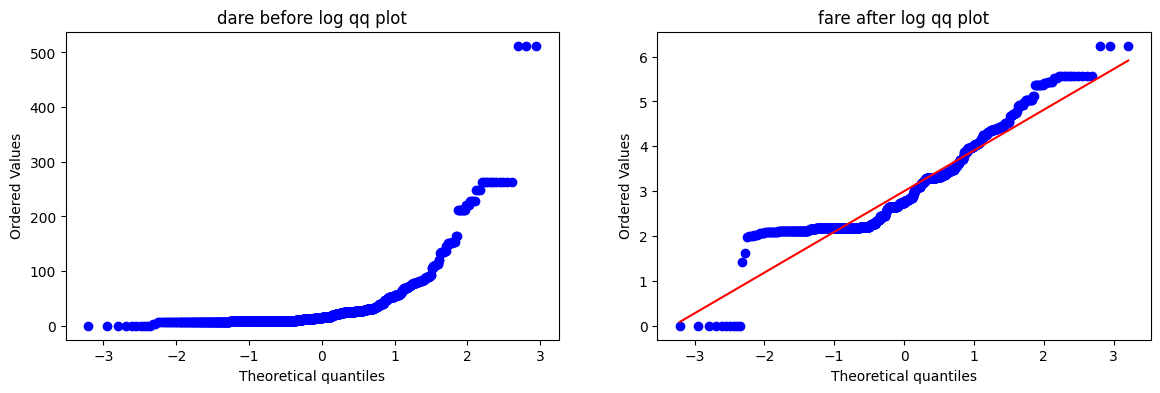

In [32]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['fare'],dist="norm",plot=plt)
plt.title('dare before log qq plot')

plt.subplot(122)
stats.probplot(X_train_trf['fare'],dist="norm",plot=plt)
plt.title('fare after log qq plot')
plt.show()

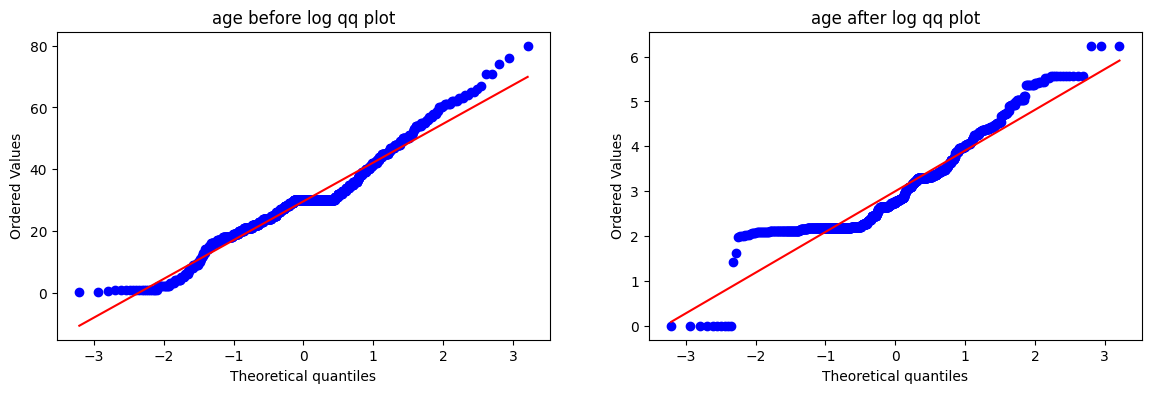

In [33]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['age'],dist="norm",plot=plt)
plt.title('age before log qq plot')

plt.subplot(122)
stats.probplot(X_train_trf['fare'],dist="norm",plot=plt)
plt.title('age after log qq plot')
plt.show()